In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
path = "../Datos_Fin.csv"
df_ml = pd.read_csv(path)
df_ml['Date'] = pd.to_datetime(df_ml['Date'])

In [63]:
df_ml.head()

,Date,Close,Ticker,Return
0,1995-12-05,0.296162,AAPL,0.000000
1,1995-12-05,4.360668,ABT,0.018927
2,1995-12-05,8.791585,ADBE,0.034050
3,1995-12-05,5.805072,ADI,-0.013072
4,1995-12-05,4.210493,AMAT,-0.021053


# Un solo caso NVDA

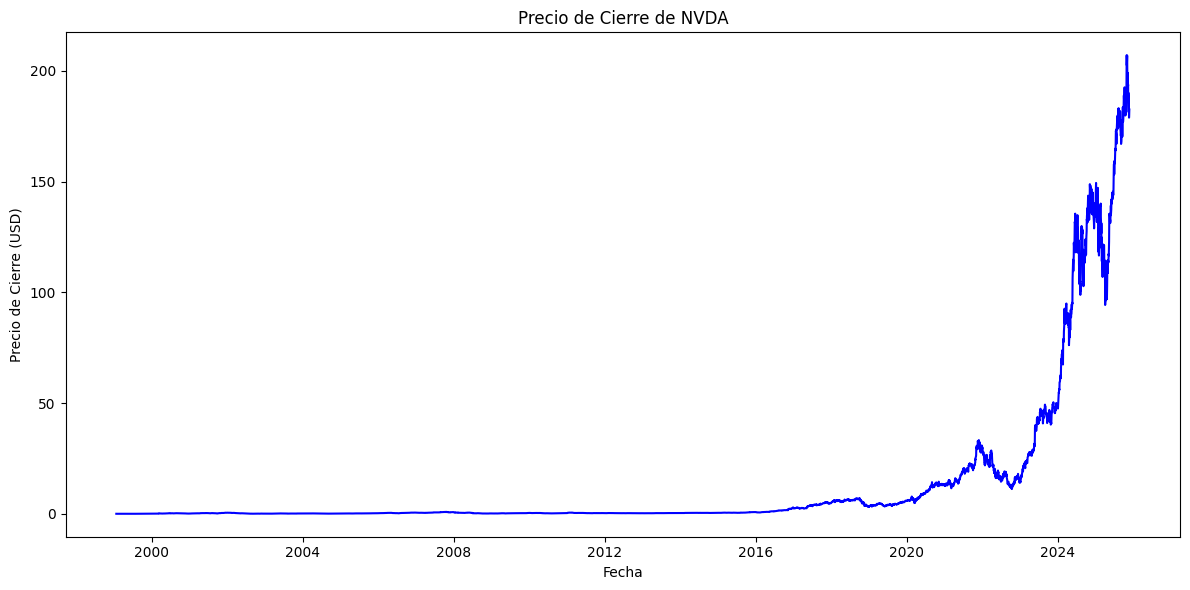

In [64]:
ticket = "NVDA"
datos_ticket = df_ml[df_ml['Ticker'] == ticket]
plt.figure(figsize=(12, 6))
plt.plot(datos_ticket['Date'], datos_ticket['Close'], color='blue')
plt.title(f"Precio de Cierre de {ticket}")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.tight_layout()
plt.show()

# Probando con ventanas


In [65]:
ultimos_2_anios = pd.Timestamp.now() - pd.DateOffset(days=730)
datos_recientes = datos_ticket[datos_ticket['Date'] >= ultimos_2_anios].copy()
datos_recientes = datos_recientes.sort_values(by='Date')
datos_recientes = datos_recientes.reset_index(drop=True)

### Definición de Variables
Sea $t$ el índice del **día actual**.
Sea $R_t$ el retorno de la acción en el día $t$.

---

### 1. Características de Entrada ($X$)
El modelo recibe una ventana de **15 días** de historia de retornos conocidos.

*   **Ventana:** 15 días (`window_auto_regresion`).
*   **Rango de Índices:** Desde $t-14$ hasta $t$.
*   **Vector de Entrada:**
    $$X_t = [R_{t-14}, R_{t-13}, \dots, R_{t-1}, R_t]$$

---

### 2. Variable Objetivo ($y$)
El modelo intenta estimar el **promedio** de los retornos de los siguientes **5 días**.

*   **Ventana:** 5 días (`ventana_prediccion`).
*   **Rango de Índices:** Desde $t+1$ hasta $t+5$.
*   **Cálculo:**
    $$y_t = \frac{R_{t+1} + R_{t+2} + R_{t+3} + R_{t+4} + R_{t+5}}{5}$$

---

### 3. Relación Temporal y Solapamiento
Es crucial notar que **NO hay solapamiento (overlapping)** entre los datos usados para generar $X$ y los datos usados para calcular $y$ para una misma muestra.

*   **Fin de $X$:** Día $t$.
*   **Inicio de $y$:** Día $t+1$.

**Esquema de Índices:**

| Día | $t-14 \dots t$ | $t$ (Hoy) | $t+1$ | $\dots$ | $t+5$ |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Datos** | Historia | Último dato conocido | Futuro 1 | $\dots$ | Futuro 5 |
| **Rol** | **Features ($X$)** | **Fin de Features** | **Inicio Target ($y$)** | $\dots$ | **Fin Target** |



# Análisis de Índices en el Punto de Corte (Train/Test Split)

### 1. Definición del Punto de Corte
Supongamos que el índice de corte es $S$ (`train_optimizacion_modelo`).
Sea $t$ el día correspondiente al **último dato de entrada** del conjunto de entrenamiento ($X_{train}[-1]$).

### 2. Última Muestra de Entrenamiento ($i = S-1$)
*   **Input ($X_{train}$):** Termina en el día $t$. Contiene historia hasta hoy.
*   **Target ($y_{train}$):** Es el promedio de los retornos de los días $[t+1, t+2, t+3, t+4, t+5]$.
    *   *Nota:* Para calcular este target, necesitamos conocer el futuro hasta $t+5$.

### 3. Primera Muestra de Prueba ($i = S$)
*   **Input ($X_{test}$):** Termina en el día $t+1$.
    *   El vector incluye el dato del día $t+1$.
*   **Target ($y_{test}$):** Es el promedio de los retornos de los días $[t+2, t+3, t+4, t+5, t+6]$.

### 4. Análisis de Solapamiento (Leakage/Correlación)

Existen dos problemas de solapamiento en este punto de corte inmediato:

1.  **Solapamiento Input-Target (Leve):**
    El primer input de prueba ($X_{test}$) contiene el retorno del día $t+1$. Este valor ($R_{t+1}$) es parte fundamental del cálculo del último target de entrenamiento ($y_{train}$). Aunque no es "futuro" para el test, el modelo acaba de ser entrenado para predecir una media que incluye ese valor específico.

2.  **Solapamiento Target-Target:**
    Dado que la variable objetivo es una media móvil de 5 días (`ventana_prediccion`), los targets son altamente autocorrelacionados.
    *   $y_{train}[-1]$ usa: $\{R_{t+1}, R_{t+2}, R_{t+3}, R_{t+4}, R_{t+5}\}$
    *   $y_{test}[0]$ usa: $\{R_{t+2}, R_{t+3}, R_{t+4}, R_{t+5}, R_{t+6}\}$
    
    **Comparten 4 de los 5 valores (80% de los datos).**
    Si evalúas el modelo inmediatamente después del corte, el error de predicción en la primera muestra de test estará altamente correlacionado con el error de la última muestra de train, inflando artificialmente las métricas de rendimiento (R² o Accuracy).

### 5. Conclusión y Recomendación


Para garantizar que la evaluación en el conjunto de prueba sea independiente de los datos específicos que formaron el target del entrenamiento, se debe saltar una ventana igual al tamaño de la prediccion.

*   **Margen recomendado:** `ventana_prediccion` (5 muestras).


In [66]:
display(datos_recientes.head(8))

,Date,Close,Ticker,Return
0,2023-11-28,47.792831,NVDA,-0.008727
1,2023-11-29,48.111649,NVDA,0.006671
2,2023-11-30,46.742451,NVDA,-0.028459
3,2023-12-01,46.737453,NVDA,-0.000107
4,2023-12-04,45.483196,NVDA,-0.026836
5,2023-12-05,46.542664,NVDA,0.023294
6,2023-12-06,45.480198,NVDA,-0.022828
7,2023-12-07,46.572647,NVDA,0.024020


In [67]:
window_auto_regresion = 15
ventana_prediccion = 5
datos_recientes['return'] = datos_recientes['Close'].pct_change()
X_lags = {}
X_lags['date'] = datos_recientes['Date'].tolist()
X_lags['idx'] = datos_recientes.index.tolist()
X_lags.update({
    f'lag_{i}': [] for i in range(window_auto_regresion)
})
X_lags.update({
    f'future_return_{i}': [] for i in range(ventana_prediccion)
})
for i in range(len(datos_recientes)):
    for j in range(window_auto_regresion):
        if i - j >= 0:
            X_lags[f'lag_{j}'].append(datos_recientes.loc[i - j, 'return'])
        else:
            X_lags[f'lag_{j}'].append(pd.NA)
    for k in range(ventana_prediccion):
        if i + k + 1 < len(datos_recientes):
            X_lags[f'future_return_{k}'].append(datos_recientes.loc[i + k + 1, 'return'])
        else:
            X_lags[f'future_return_{k}'].append(pd.NA)

data = pd.DataFrame(X_lags)
data = data.dropna().reset_index(drop=True)
display(data.head(10))
display(datos_recientes.head(20))
train_index = int(0.85 * len(data))
data_train_split = data.iloc[:train_index]
data_test_split = data.iloc[train_index + ventana_prediccion:]
display(data_train_split.tail(5))
display(data_test_split.head(5))

,date,idx,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_10,lag_11,lag_12,lag_13,lag_14,future_return_0,future_return_1,future_return_2,future_return_3,future_return_4
0,2023-12-19,15,-0.009446,0.024279,0.011169,0.005448,0.009044,0.02209,-0.018503,0.01953,...,0.023294,-0.026836,-0.000107,-0.028459,0.006671,-0.030098,0.018271,-0.003266,0.009195,0.0028
1,2023-12-20,16,-0.030098,-0.009446,0.024279,0.011169,0.005448,0.009044,0.02209,-0.018503,...,-0.022828,0.023294,-0.026836,-0.000107,-0.028459,0.018271,-0.003266,0.009195,0.0028,0.002125
2,2023-12-21,17,0.018271,-0.030098,-0.009446,0.024279,0.011169,0.005448,0.009044,0.02209,...,0.02402,-0.022828,0.023294,-0.026836,-0.000107,-0.003266,0.009195,0.0028,0.002125,0.0
3,2023-12-22,18,-0.003266,0.018271,-0.030098,-0.009446,0.024279,0.011169,0.005448,0.009044,...,0.01953,0.02402,-0.022828,0.023294,-0.026836,0.009195,0.0028,0.002125,0.0,-0.027341
4,2023-12-26,19,0.009195,-0.003266,0.018271,-0.030098,-0.009446,0.024279,0.011169,0.005448,...,-0.018503,0.01953,0.02402,-0.022828,0.023294,0.0028,0.002125,0.0,-0.027341,-0.012436
5,2023-12-27,20,0.002800,0.009195,-0.003266,0.018271,-0.030098,-0.009446,0.024279,0.011169,...,0.02209,-0.018503,0.01953,0.02402,-0.022828,0.002125,0.0,-0.027341,-0.012436,0.009019
6,2023-12-28,21,0.002125,0.0028,0.009195,-0.003266,0.018271,-0.030098,-0.009446,0.024279,...,0.009044,0.02209,-0.018503,0.01953,0.02402,0.0,-0.027341,-0.012436,0.009019,0.022897
7,2023-12-29,22,0.000000,0.002125,0.0028,0.009195,-0.003266,0.018271,-0.030098,-0.009446,...,0.005448,0.009044,0.02209,-0.018503,0.01953,-0.027341,-0.012436,0.009019,0.022897,0.064281
8,2024-01-02,23,-0.027341,0.0,0.002125,0.0028,0.009195,-0.003266,0.018271,-0.030098,...,0.011169,0.005448,0.009044,0.02209,-0.018503,-0.012436,0.009019,0.022897,0.064281,0.016975
9,2024-01-03,24,-0.012436,-0.027341,0.0,0.002125,0.0028,0.009195,-0.003266,0.018271,...,0.024279,0.011169,0.005448,0.009044,0.02209,0.009019,0.022897,0.064281,0.016975,0.02277


,Date,Close,Ticker,Return,return
0,2023-11-28,47.792831,NVDA,-0.008727,NaN
1,2023-11-29,48.111649,NVDA,0.006671,0.006671
2,2023-11-30,46.742451,NVDA,-0.028459,-0.028459
3,2023-12-01,46.737453,NVDA,-0.000107,-0.000107
4,2023-12-04,45.483196,NVDA,-0.026836,-0.026836
5,2023-12-05,46.542664,NVDA,0.023294,0.023294
6,2023-12-06,45.480198,NVDA,-0.022828,-0.022828
7,2023-12-07,46.572647,NVDA,0.024020,0.024020
8,2023-12-08,47.482189,NVDA,0.019530,0.019530
9,2023-12-11,46.603630,NVDA,-0.018503,-0.018503


,date,idx,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_10,lag_11,lag_12,lag_13,lag_14,future_return_0,future_return_1,future_return_2,future_return_3,future_return_4
403,2025-07-31,418,-0.007810,0.021423,-0.007016,0.018732,-0.001381,0.017332,0.022451,-0.025382,...,0.009512,0.003925,0.040409,-0.005154,0.004997,-0.023332,0.03615,-0.009667,0.006507,0.007524
404,2025-08-01,419,-0.023332,-0.00781,0.021423,-0.007016,0.018732,-0.001381,0.017332,0.022451,...,-0.00341,0.009512,0.003925,0.040409,-0.005154,0.03615,-0.009667,0.006507,0.007524,0.010677
405,2025-08-04,420,0.036150,-0.023332,-0.00781,0.021423,-0.007016,0.018732,-0.001381,0.017332,...,-0.005974,-0.00341,0.009512,0.003925,0.040409,-0.009667,0.006507,0.007524,0.010677,-0.003503
406,2025-08-05,421,-0.009667,0.03615,-0.023332,-0.00781,0.021423,-0.007016,0.018732,-0.001381,...,-0.025382,-0.005974,-0.00341,0.009512,0.003925,0.006507,0.007524,0.010677,-0.003503,0.006042
407,2025-08-06,422,0.006507,-0.009667,0.03615,-0.023332,-0.00781,0.021423,-0.007016,0.018732,...,0.022451,-0.025382,-0.005974,-0.00341,0.009512,0.007524,0.010677,-0.003503,0.006042,-0.008572


,date,idx,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_10,lag_11,lag_12,lag_13,lag_14,future_return_0,future_return_1,future_return_2,future_return_3,future_return_4
413,2025-08-14,428,0.002368,-0.008572,0.006042,-0.003503,0.010677,0.007524,0.006507,-0.009667,...,-0.00781,0.021423,-0.007016,0.018732,-0.001381,-0.008625,0.008645,-0.034998,-0.001366,-0.002395
414,2025-08-15,429,-0.008625,0.002368,-0.008572,0.006042,-0.003503,0.010677,0.007524,0.006507,...,-0.023332,-0.00781,0.021423,-0.007016,0.018732,0.008645,-0.034998,-0.001366,-0.002395,0.017202
415,2025-08-18,430,0.008645,-0.008625,0.002368,-0.008572,0.006042,-0.003503,0.010677,0.007524,...,0.03615,-0.023332,-0.00781,0.021423,-0.007016,-0.034998,-0.001366,-0.002395,0.017202,0.010225
416,2025-08-19,431,-0.034998,0.008645,-0.008625,0.002368,-0.008572,0.006042,-0.003503,0.010677,...,-0.009667,0.03615,-0.023332,-0.00781,0.021423,-0.001366,-0.002395,0.017202,0.010225,0.0109
417,2025-08-20,432,-0.001366,-0.034998,0.008645,-0.008625,0.002368,-0.008572,0.006042,-0.003503,...,0.006507,-0.009667,0.03615,-0.023332,-0.00781,-0.002395,0.017202,0.010225,0.0109,-0.000935


In [68]:
X_opt = data_train_split.drop(columns=['date', 'idx'] + [f'future_return_{i}' for i in range(ventana_prediccion)])
X_opt = X_opt.values
y_opt = data_train_split[[f'future_return_{i}' for i in range(ventana_prediccion)]]
y_opt = np.mean(y_opt.values, axis=1)
X_test_final = data_test_split.drop(columns=['date', 'idx'] + [f'future_return_{i}' for i in range(ventana_prediccion)])
X_test_final = X_test_final.values
y_test_final = data_test_split[[f'future_return_{i}' for i in range(ventana_prediccion)]]
y_test_final = np.mean(y_test_final.values, axis=1)
print(f"Tamaño conjunto optimización: {X_opt.shape}, Tamaño conjunto prueba final: {X_test_final.shape}")
print(f'Tamaño y_opt: {y_opt.shape}, tamaño y_test_final: {y_test_final.shape}')

Tamaño conjunto optimización: (408, 15), Tamaño conjunto prueba final: (67, 15)
Tamaño y_opt: (408,), tamaño y_test_final: (67,)


In [69]:
print(type(X_opt), type(y_opt), type(X_test_final), type(y_test_final))

<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [70]:
def evaluar_modelo_series_temporales(X_train,X_test, y_train, y_test, modelo, nombre_activo="Activo",fit=False,plot=False):
    """
    Evalúa un modelo de regresión para series temporales.
    
    Parámetros:
    -----------
    X : numpy.ndarray
        Features de entrada (matriz de características)
    y : numpy.ndarray
        Variable objetivo (valores a predecir)
    modelo : sklearn estimator
        Modelo de sklearn ya entrenado o por entrenar
    train_size : float, opcional (default=0.8)
        Proporción de datos para entrenamiento
    nombre_activo : str, opcional (default="Activo")
        Nombre del activo para los títulos de gráficos
    
    Retorna:
    --------
    dict : Diccionario con métricas y predicciones
    """
    from sklearn.metrics import r2_score, recall_score, confusion_matrix, precision_score
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Entrenar modelo
    if fit:
        modelo.fit(X_train, y_train)
    # Predicciones
    y_pred = modelo.predict(X_test)
    y_train_pred = modelo.predict(X_train)

    # Métricas de regresión
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_pred)

    # Clasificación binaria (dirección del retorno)
    y_pred_bin = np.where(y_pred > 0, 1, 0)
    y_test_bin = np.where(y_test > 0, 1, 0)

    # Métricas de clasificación
    recall = recall_score(y_test_bin, y_pred_bin)
    accuracy = np.mean(y_pred_bin == y_test_bin)
    precision = precision_score(y_test_bin, y_pred_bin)

    print(f"Recall Dirección del Retorno Promedio 5D para {nombre_activo}: {recall:.4f}")
    print(f"Precision Dirección del Retorno Promedio 5D para {nombre_activo}: {precision:.4f}")
    print(f"Accuracy Dirección del Retorno Promedio 5D para {nombre_activo}: {accuracy:.4f}")
    cm = confusion_matrix(y_test_bin, y_pred_bin)   
    # Crear subplots
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Gráfico de entrenamiento
        axes[0, 0].plot(y_train, label='Valores Reales de Entrenamiento', color='blue', marker='o')
        axes[0, 0].plot(y_train_pred, label='Predicciones de Entrenamiento', color='orange', marker='x')
        axes[0, 0].set_title(f'Predicción del Retorno Promedio 5D para {nombre_activo} (R² = {r2_train:.4f})')
        axes[0, 0].set_xlabel('Muestras de Entrenamiento')
        axes[0, 0].set_ylabel('Retorno Promedio 5D')
        axes[0, 0].legend()
        axes[0, 0].grid()
        
        # Gráfico de prueba
        axes[0, 1].plot(y_test, label='Valores Reales del Retorno Promedio 5D', color='blue', marker='o')
        axes[0, 1].plot(y_pred, label='Predicciones del Retorno Promedio 5D', color='orange', marker='x')
        axes[0, 1].set_title(f'Predicción del Retorno Promedio 5D para {nombre_activo} (R² = {r2_test:.4f})')
        axes[0, 1].set_xlabel('Muestras de Prueba')
        axes[0, 1].set_ylabel('Retorno Promedio 5D')
        axes[0, 1].legend()
        axes[0, 1].grid()

        # Matriz de confusión
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
        axes[1, 0].set_title(f'Matriz de Confusión para la Dirección del Retorno Promedio 5D de {nombre_activo}')
        axes[1, 0].set_xlabel('Predicción')
        axes[1, 0].set_ylabel('Valor Real')
        # Gráfico de la serie completa real
        y_real = np.concatenate([y_train, y_test])
        axes[1, 1].plot(y_real, label='Serie Completa Real', color='blue', alpha=0.7)
        axes[1, 1].set_title(f'Serie Completa del Retorno Promedio 5D de {nombre_activo}')
        axes[1, 1].set_xlabel('Índice Temporal')
        axes[1, 1].set_ylabel('Retorno Promedio 5D')
        axes[1, 1].legend()
        axes[1, 1].grid()

        plt.tight_layout()
        plt.show()
    # Retornar resultados
    resultados = {
        'modelo': modelo,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'recall': recall,
        'precision': precision_score(y_test_bin, y_pred_bin),
        'accuracy': accuracy,
        'y_pred': y_pred,
        'y_test': y_test,
        'y_pred_bin': y_pred_bin,
        'y_test_bin': y_test_bin,
        'confusion_matrix': cm
    }
    return resultados

# CV Temporales
Acumulatvio

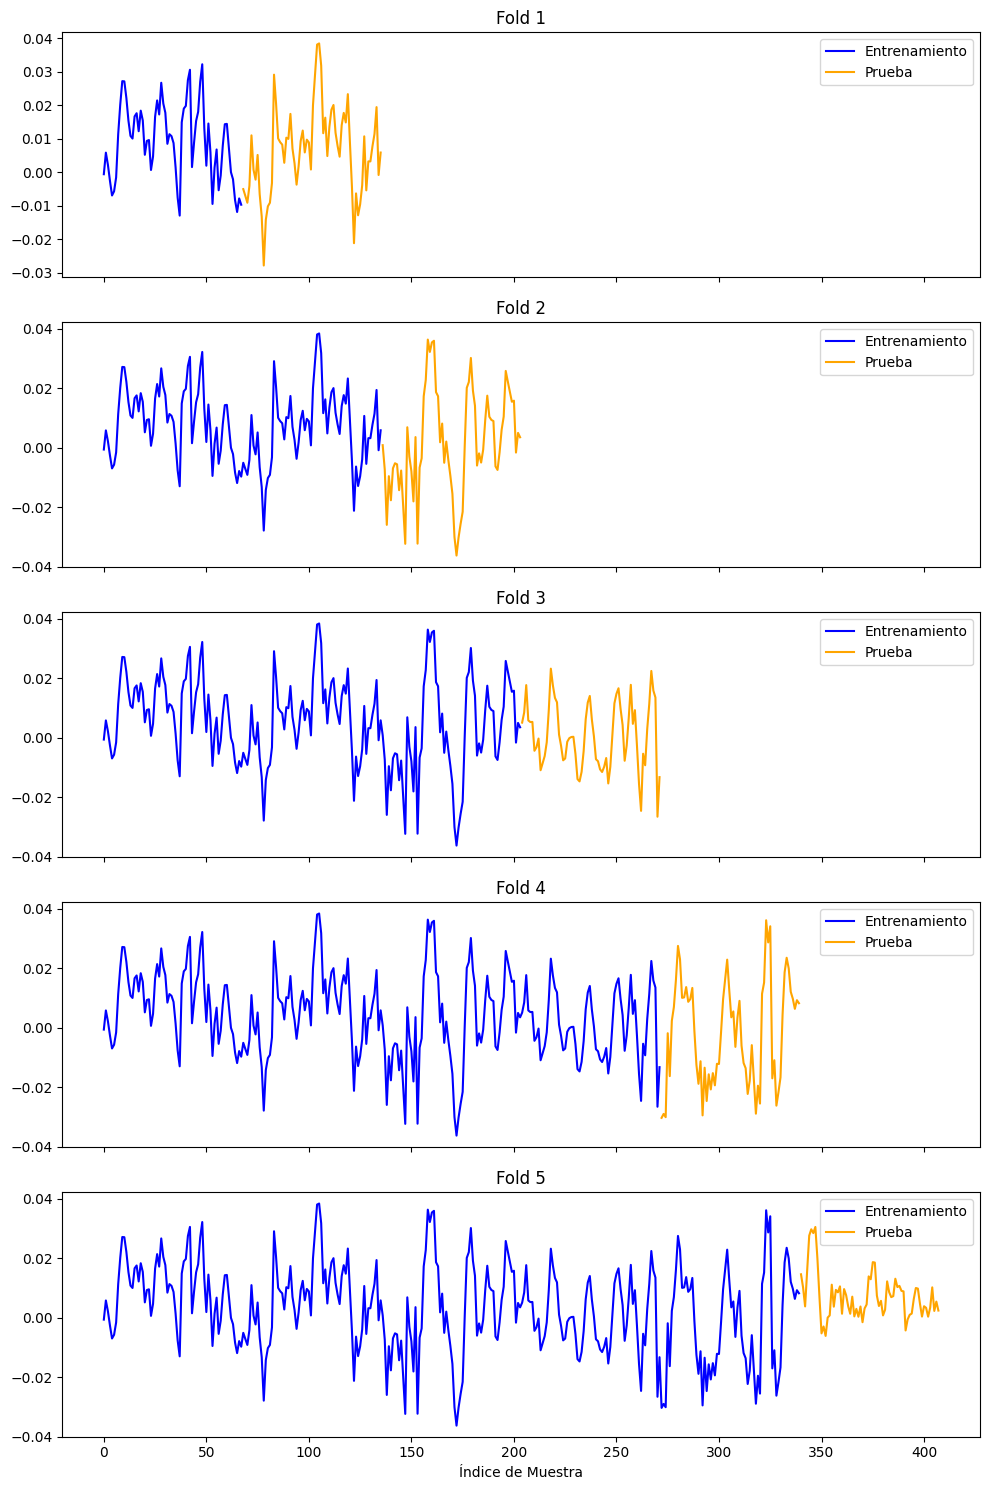

In [71]:
from sklearn.model_selection import TimeSeriesSplit
num_folds = 5
tscv = TimeSeriesSplit(n_splits=num_folds)
#graficar por colores como luce este split
fig,axe = plt.subplots(nrows=num_folds, ncols=1, figsize=(10, 15),sharex=True)
axe = axe.flatten()
for fold, (train_index, test_index) in enumerate(tscv.split(X_opt)):
    y_train_fold = y_opt[train_index]
    y_test_fold = y_opt[test_index]
    axe[fold].plot(train_index, y_train_fold, label='Entrenamiento', color='blue')
    axe[fold].plot(test_index, y_test_fold, label='Prueba', color='orange')
    axe[fold].set_title(f'Fold {fold + 1}')
    axe[fold].legend()
plt.xlabel('Índice de Muestra')
plt.tight_layout()
plt.show()



Por bloque, este es el que nos interesa

In [72]:
class BlockedTimeSeriesSplit():
    def __init__(self, n_splits, train_size=0.8, margin=0):
        self.n_splits = n_splits
        self.train_size = train_size
        self.margin = margin # Nuevo parámetro para el gap

    def get_n_splits(self, X, y, groups):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        k_fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)

        for i in range(self.n_splits):
            start = i * k_fold_size
            stop = start + k_fold_size
            mid = int(self.train_size * (stop - start)) + start
            
            # Aseguramos que el margen no haga que el test empiece después del stop
            if mid + self.margin < stop:
                yield indices[start: mid], indices[mid + self.margin: stop]
            else:
                # Fallback por si el bloque es muy pequeño
                yield indices[start: mid], indices[mid: stop]


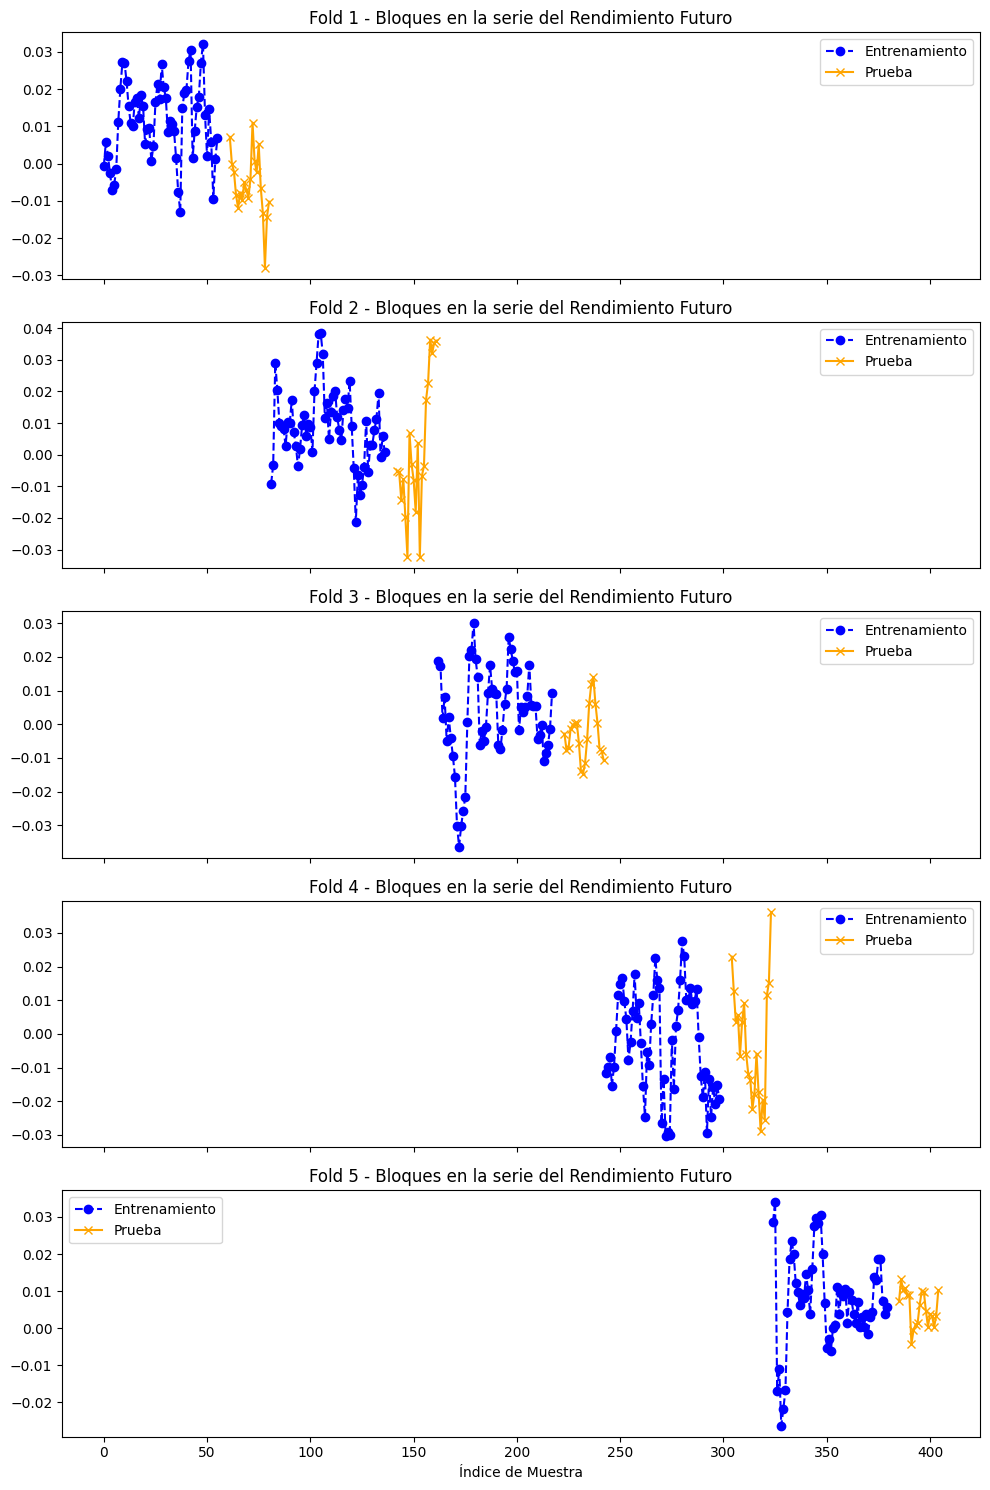

In [73]:
num_folds = 5
# se salta esa ventana de predicción entre train y test en cada fold
bscv = BlockedTimeSeriesSplit(n_splits=num_folds, train_size=0.7, margin=ventana_prediccion)
#graficar por colores como luce este split
fig,axe = plt.subplots(nrows=num_folds, ncols=1, figsize=(10, 15),sharex=True)
axe = axe.flatten()
for fold, (train_index, test_index) in enumerate(bscv.split(X_opt)):
    y_train_fold = y_opt[train_index]
    y_test_fold = y_opt[test_index]
    axe[fold].plot(train_index, y_train_fold, label='Entrenamiento', color='blue', marker='o',linestyle='--')
    axe[fold].plot(test_index, y_test_fold, label='Prueba', color='orange', marker='x')
    axe[fold].set_title(f'Fold {fold + 1} - Bloques en la serie del Rendimiento Futuro')
    axe[fold].legend()
plt.xlabel('Índice de Muestra')
plt.tight_layout()
plt.show()

# Optimizacion Bayesiana con Block CV

In [74]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.ensemble import RandomForestRegressor

params_rf = {
    "n_estimators": Integer(50, 500),
    "max_depth": Integer(3, 20),
    "min_samples_split": Integer(2, 20),
    "min_samples_leaf": Integer(2, 10),
    "max_features": Real(0.1, 1.0, prior='uniform')
}


search_rf = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    search_spaces=params_rf,
    n_iter=10,
    cv=bscv,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    random_state=42
)
search_rf.fit(X_opt, y_opt)


,estimator,RandomForestR...ndom_state=42)
,search_spaces,"{'max_depth': Integer(low=3...m='normalize'), 'max_features': Real(low=0.1,...m='normalize'), 'min_samples_leaf': Integer(low=2...m='normalize'), 'min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,10
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,<__main__.Blo...00199FB453E00>


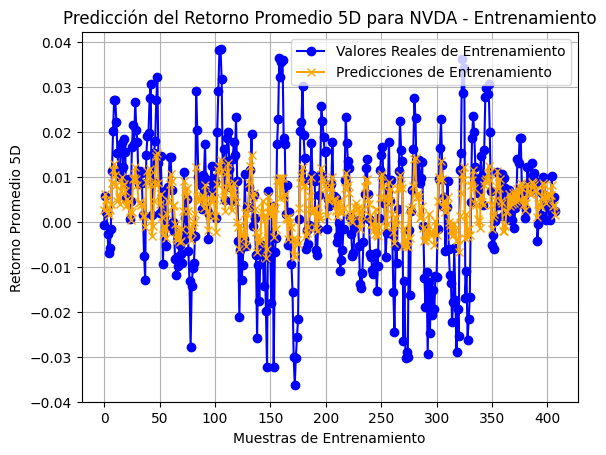

In [75]:
y_pred_rf_train = search_rf.best_estimator_.predict(X_opt)
plt.plot(y_opt, label='Valores Reales de Entrenamiento', color='blue', marker='o')
plt.plot(y_pred_rf_train, label='Predicciones de Entrenamiento', color='orange', marker='x')
plt.title(f'Predicción del Retorno Promedio 5D para {ticket} - Entrenamiento')
plt.xlabel('Muestras de Entrenamiento')
plt.ylabel('Retorno Promedio 5D')
plt.legend()
plt.grid()
plt.show()

Recall Dirección del Retorno Promedio 5D para NVDA: 1.0000
Precision Dirección del Retorno Promedio 5D para NVDA: 0.5231
Accuracy Dirección del Retorno Promedio 5D para NVDA: 0.5373


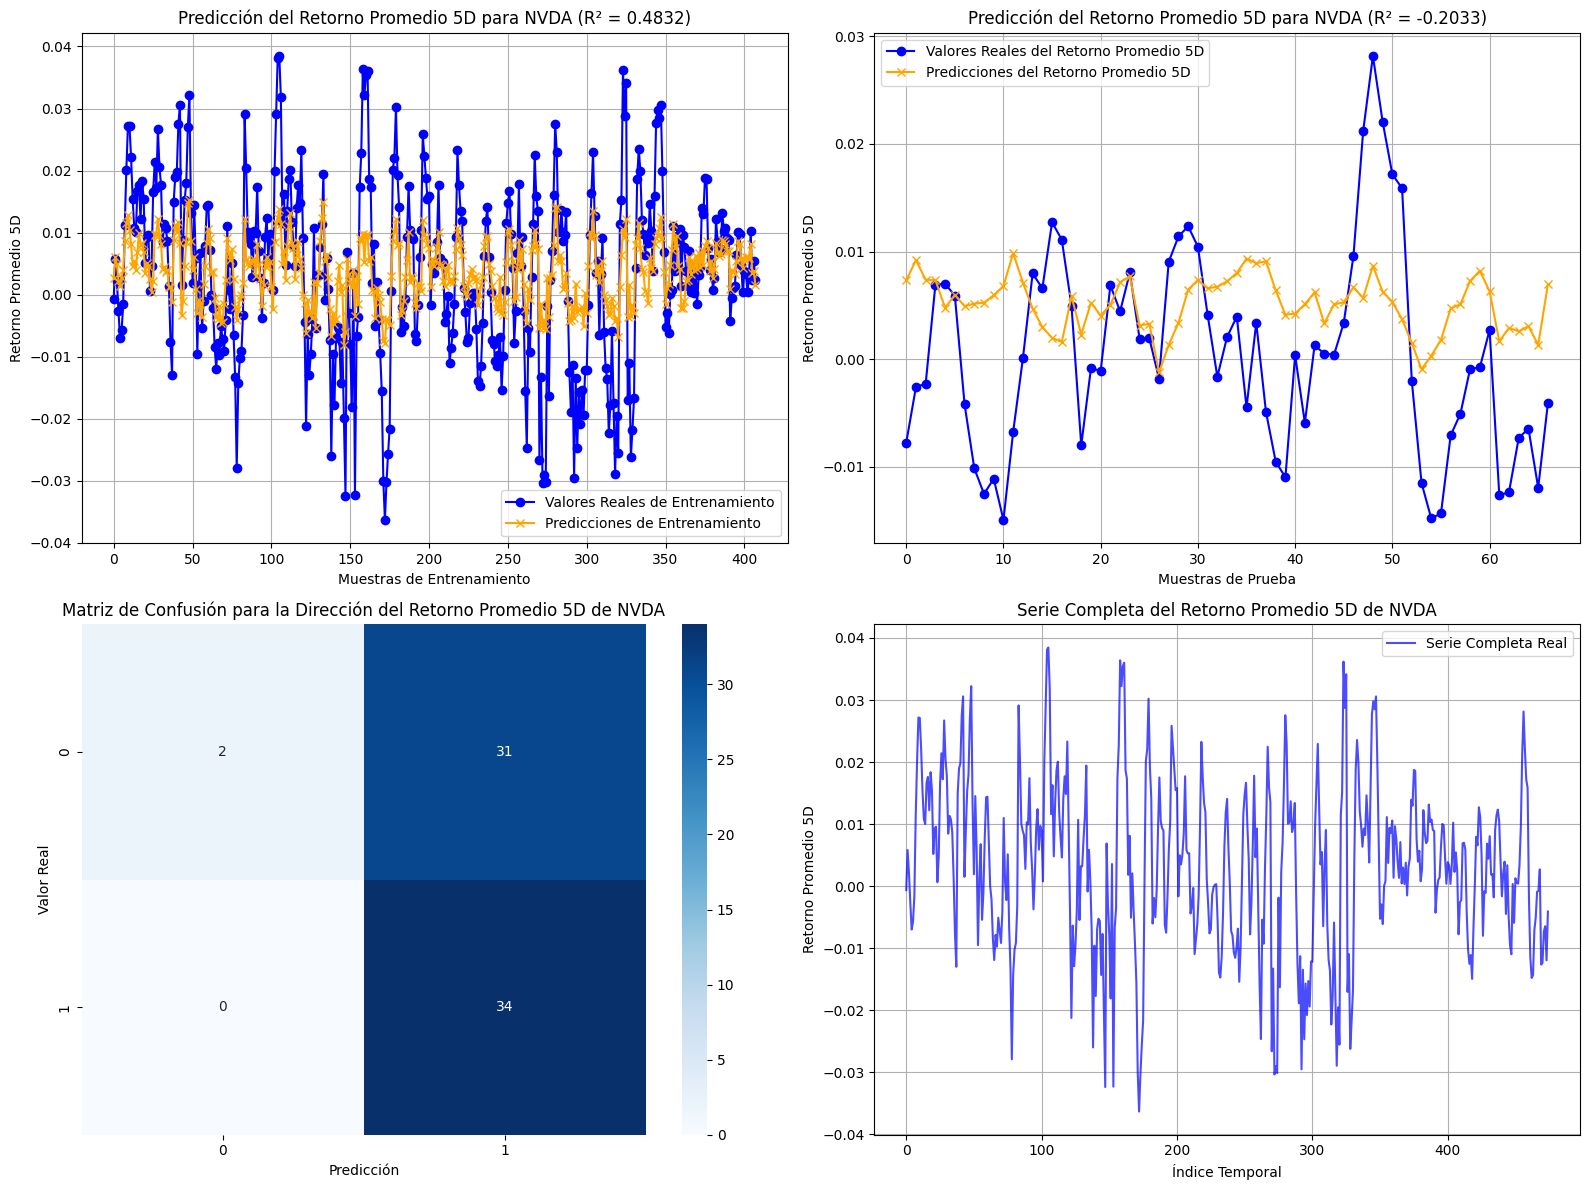

In [76]:
best_rf = search_rf.best_estimator_
resultados = evaluar_modelo_series_temporales(X_opt, X_test_final, y_opt, y_test_final, best_rf, nombre_activo=ticket, fit=False, plot=True)